# Model-independent GEDF reconstruction of $w(z)$

This notebook loads the Cobaya chains with GetDist, reports weighted posterior means and standard deviations, and propagates the full MCMC posterior into the pointwise mean and $\pm1\sigma$ band of $w(z)$. The reconstruction implements the same shape-preserving cubic Hermite interpolation in $x=\ln a$ as the `feat-model-independent-gedf` CLASS branch, and is checked against CLASS's `(.)w_gedf` background output.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-wz-mcmc")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getdist import loadMCSamples
from classy import Class

CLASS_DIR = Path("/home/lutein/Projects/class-gedf-test-04")
CHAIN_DIR = Path("/home/lutein/jupyter/Chains/260820_gedf_reconstruct")
CHAIN_ROOT = CHAIN_DIR / "260821_gedf_reconstruct_test"
BURN_IN = 0.30

assert CLASS_DIR.exists()
assert Path(str(CHAIN_ROOT) + ".1.txt").exists()
print(f"CLASS checkout: {CLASS_DIR}")
print(f"Chain root:     {CHAIN_ROOT}")

CLASS checkout: /home/lutein/Projects/class-gedf-test-04
Chain root:     /home/lutein/jupyter/Chains/260820_gedf_reconstruct/260821_gedf_reconstruct_test


## GetDist posterior parameter summary

`no_cache=True` avoids writing GetDist's cache beside these read-only chains. The first 30% of every chain is discarded as burn-in; change `BURN_IN` above if a different cut is desired.

In [2]:
samples = loadMCSamples(
    str(CHAIN_ROOT),
    no_cache=True,
    settings={"ignore_rows": BURN_IN},
)

parameter_names = [
    "omega_b", "omega_cdm", "theta_s_1e2", "logA", "A_s",
    "n_s", "tau_reio", "wi_gedf", "gedf_node_w_1",
    "gedf_node_w_2", "gedf_node_w_3", "wf_gedf", "f_gedf",
    "H0", "sigma8", "Omega_m",
]
summary = pd.DataFrame(
    {
        "mean": [samples.mean(name) for name in parameter_names],
        "std (1 sigma)": [samples.std(name) for name in parameter_names],
    },
    index=parameter_names,
)
summary.index.name = "parameter"
print(f"Post-burn-in rows: {samples.numrows:,}")
print(f"Total sample weight: {samples.weights.sum():,.0f}")
summary

/home/lutein/jupyter/Chains/260820_gedf_reconstruct/260821_gedf_reconstruct_test.1.txt
/home/lutein/jupyter/Chains/260820_gedf_reconstruct/260821_gedf_reconstruct_test.2.txt
/home/lutein/jupyter/Chains/260820_gedf_reconstruct/260821_gedf_reconstruct_test.3.txt
/home/lutein/jupyter/Chains/260820_gedf_reconstruct/260821_gedf_reconstruct_test.4.txt
Removed 0.3 as burn in
Post-burn-in rows: 79,007
Total sample weight: 79,591


,mean,std (1 sigma)
parameter,,
omega_b,2.301671e-02,1.504194e-04
omega_cdm,1.283829e-01,2.873675e-03
theta_s_1e2,1.041162e+00,2.806661e-04
logA,3.077819e+00,1.294554e-02
A_s,2.171283e-09,2.813445e-11
n_s,9.892185e-01,5.040385e-03
tau_reio,6.280531e-02,5.733713e-03
wi_gedf,-8.300198e-01,1.330556e-01
gedf_node_w_1,-4.897259e-01,2.894920e-01


## Reconstruct and propagate $w(z)$

The CLASS branch fixes the redshift control points to $z=(5000,4000,3000,2000,1000)$ and interpolates the sampled values $(w_i,w_1,w_2,w_3,w_f)$ with a PCHIP in $\ln a=-\ln(1+z)$. End-point slopes are zero and the equation of state is constant outside the reconstructed interval. The calculation below is chunked so that all weighted samples are used without allocating a large chain-by-redshift matrix.

In [3]:
W_NAMES = [
    "wi_gedf", "gedf_node_w_1", "gedf_node_w_2",
    "gedf_node_w_3", "wf_gedf",
]
Z_NODES = np.array([5000.0, 4000.0, 3000.0, 2000.0, 1000.0])
X_NODES = -np.log1p(Z_NODES)
W_COLUMNS = [samples.index[name] for name in W_NAMES]

def gedf_w_curves(z, w_values, tension=0.0):
    """Vectorized copy of background_w_gedf_reconstructed in CLASS."""
    z = np.asarray(z, dtype=float)
    values = np.atleast_2d(np.asarray(w_values, dtype=float))
    if values.shape[1] != len(X_NODES):
        raise ValueError(f"Expected {len(X_NODES)} w control values")

    slopes = np.zeros_like(values)
    for i in range(1, len(X_NODES) - 1):
        hm = X_NODES[i] - X_NODES[i - 1]
        hp = X_NODES[i + 1] - X_NODES[i]
        dm = (values[:, i] - values[:, i - 1]) / hm
        dp = (values[:, i + 1] - values[:, i]) / hp
        valid = (dm != 0.0) & (dp != 0.0) & (dm * dp > 0.0)
        slopes[valid, i] = (1.0 - tension) * (
            (2.0 * hp + hm + hp + 2.0 * hm)
            / ((2.0 * hp + hm) / dm[valid] + (hp + 2.0 * hm) / dp[valid])
        )

    x = -np.log1p(z)
    result = np.empty((values.shape[0], z.size), dtype=float)
    result[:, x <= X_NODES[0]] = values[:, [0]]
    result[:, x >= X_NODES[-1]] = values[:, [-1]]

    for i in range(len(X_NODES) - 1):
        inside = (x > X_NODES[i]) & (x < X_NODES[i + 1])
        if not np.any(inside):
            continue
        h = X_NODES[i + 1] - X_NODES[i]
        t = (x[inside] - X_NODES[i]) / h
        result[:, inside] = (
            values[:, [i]] * (2.0 * t**3 - 3.0 * t**2 + 1.0)
            + slopes[:, [i]] * h * (t**3 - 2.0 * t**2 + t)
            + values[:, [i + 1]] * (-2.0 * t**3 + 3.0 * t**2)
            + slopes[:, [i + 1]] * h * (t**3 - t**2)
        )
    return result

def weighted_curve_moments(z, chunk_size=5000):
    weighted_sum = np.zeros_like(z, dtype=float)
    weighted_sum_sq = np.zeros_like(z, dtype=float)
    total_weight = 0.0
    for start in range(0, samples.numrows, chunk_size):
        stop = min(start + chunk_size, samples.numrows)
        chunk_weights = samples.weights[start:stop]
        curves = gedf_w_curves(z, samples.samples[start:stop, W_COLUMNS])
        weighted_sum += chunk_weights @ curves
        weighted_sum_sq += chunk_weights @ (curves * curves)
        total_weight += chunk_weights.sum()
    mean = weighted_sum / total_weight
    variance = np.maximum(weighted_sum_sq / total_weight - mean * mean, 0.0)
    return mean, np.sqrt(variance)

z = np.linspace(500.0, 6000.0, 451)
w_mean, w_std = weighted_curve_moments(z)
print(f"Computed pointwise moments on {z.size} redshift values from all samples.")

Computed pointwise moments on 451 redshift values from all samples.


## Validate against the requested CLASS branch

CLASS is run at the GetDist posterior-mean parameters. Its native background table is compared at its own redshift samples to avoid introducing interpolation error in the validation.

In [4]:
w_parameter_mean = np.array([samples.mean(name) for name in W_NAMES])
class_params = {
    "H0": samples.mean("H0"),
    "omega_b": samples.mean("omega_b"),
    "omega_cdm": samples.mean("omega_cdm"),
    "N_ncdm": 1,
    "m_ncdm": 0.06,
    "N_ur": 2.0308,
    "use_model_independent_gedf": "yes",
    "has_gedf_perturbations": "no",
    "zi_gedf": Z_NODES[0],
    "zf_gedf": Z_NODES[-1],
    "gedf_node_count": 3,
    "gedf_node_z": "4000,3000,2000",
    "wi_gedf": w_parameter_mean[0],
    "gedf_node_w": ",".join(f"{value:.17g}" for value in w_parameter_mean[1:4]),
    "wf_gedf": w_parameter_mean[-1],
    "gedf_pchip_tension": 0.0,
    "f_gedf": samples.mean("f_gedf"),
}

cosmo = Class()
cosmo.set(class_params)
cosmo.compute()
background = cosmo.get_background()
class_z = np.asarray(background["z"])
class_w = np.asarray(background["(.)w_gedf"])
validation_mask = (class_z >= z.min()) & (class_z <= z.max())
direct_at_class_z = gedf_w_curves(
    class_z[validation_mask], w_parameter_mean
)[0]
max_abs_error = np.max(np.abs(class_w[validation_mask] - direct_at_class_z))
print(f"Maximum |w_CLASS - w_reconstruction| = {max_abs_error:.3e}")
assert max_abs_error < 2e-6

order = np.argsort(class_z)
class_mean_parameter_curve = np.interp(z, class_z[order], class_w[order])
cosmo.struct_cleanup()
cosmo.empty()

Maximum |w_CLASS - w_reconstruction| = 5.551e-16


## Posterior mean and $1\sigma$ band

The solid curve and band are the pointwise weighted posterior mean and standard deviation. The dashed curve is the CLASS result evaluated once at the vector of posterior-mean parameters; its small difference from the solid line is expected because PCHIP slopes are nonlinear functions of the sampled node values.

Saved /home/lutein/Projects/class-gedf-test-04/notebooks/wz_mcmc_mean_1sigma.png


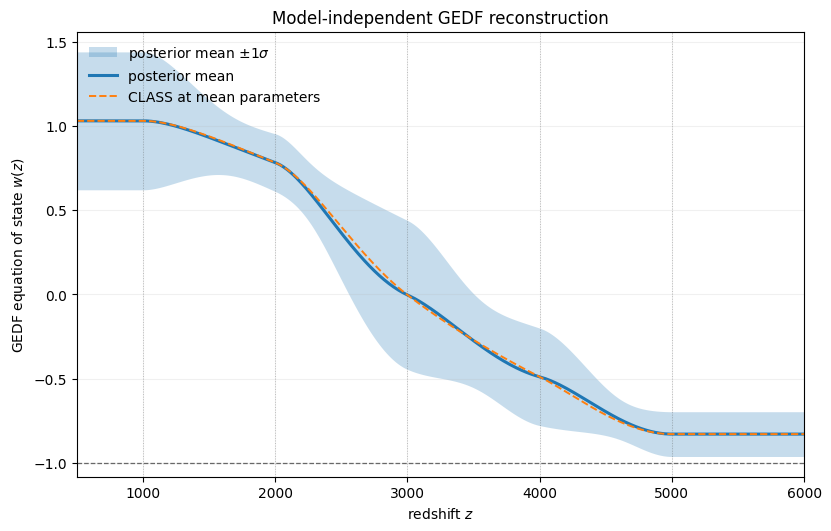

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 5.2), constrained_layout=True)
ax.fill_between(
    z, w_mean - w_std, w_mean + w_std,
    color="C0", alpha=0.25, linewidth=0, label=r"posterior mean $\pm1\sigma$",
)
ax.plot(z, w_mean, color="C0", lw=2.2, label="posterior mean")
ax.plot(
    z, class_mean_parameter_curve, color="C1", lw=1.4, ls="--",
    label="CLASS at mean parameters",
)
for node_z in Z_NODES:
    ax.axvline(node_z, color="0.75", lw=0.7, ls=":", zorder=0)
ax.axhline(-1.0, color="0.35", lw=0.9, ls="--", zorder=0)
ax.set(
    xlabel="redshift $z$",
    ylabel=r"GEDF equation of state $w(z)$",
    xlim=(z.min(), z.max()),
    title=r"Model-independent GEDF reconstruction",
)
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.18)

figure_path = CLASS_DIR / "notebooks" / "wz_mcmc_mean_1sigma.png"
fig.savefig(figure_path, dpi=180)
print(f"Saved {figure_path}")
plt.show()

## GEDF fractional density $f_{\rm gedf}(z)$

In this CLASS branch, $f_{\rm gedf}(z)=\rho_{\rm gedf}(z)/\rho_{\rm tot}(z)$, and the sampled `f_gedf` parameter fixes this fraction at $z_i=5000$. The pointwise posterior moments below come from 256 fixed-seed weighted posterior draws evaluated directly with CLASS. This resampling keeps the calculation practical while propagating the joint uncertainty in the GEDF history and the background cosmology.

In [6]:
F_GEDF_DRAWS = 256
rng = np.random.default_rng(260826)
draw_indices = rng.choice(
    samples.numrows, size=F_GEDF_DRAWS, replace=True,
    p=samples.weights / samples.weights.sum(),
)
sample_column = {name: samples.index[name] for name in [
    "H0", "omega_b", "omega_cdm", "wi_gedf",
    "gedf_node_w_1", "gedf_node_w_2", "gedf_node_w_3",
    "wf_gedf", "f_gedf",
]}

def class_f_gedf_curve(sample_index):
    row = samples.samples[sample_index]
    params = class_params.copy()
    params.update({
        "H0": row[sample_column["H0"]],
        "omega_b": row[sample_column["omega_b"]],
        "omega_cdm": row[sample_column["omega_cdm"]],
        "wi_gedf": row[sample_column["wi_gedf"]],
        "gedf_node_w": ",".join(
            f"{row[sample_column[name]]:.17g}"
            for name in ["gedf_node_w_1", "gedf_node_w_2", "gedf_node_w_3"]
        ),
        "wf_gedf": row[sample_column["wf_gedf"]],
        "f_gedf": row[sample_column["f_gedf"]],
    })
    model = Class()
    try:
        model.set(params)
        model.compute()
        bg = model.get_background()
        bg_z = np.asarray(bg["z"])
        fraction = np.asarray(bg["(.)rho_gedf"]) / np.asarray(bg["(.)rho_tot"])
        order = np.argsort(bg_z)
        return np.interp(z, bg_z[order], fraction[order])
    finally:
        model.struct_cleanup()
        model.empty()

f_gedf_curves = np.empty((F_GEDF_DRAWS, z.size))
for draw_number, sample_index in enumerate(draw_indices):
    f_gedf_curves[draw_number] = class_f_gedf_curve(sample_index)
    if (draw_number + 1) % 64 == 0:
        print(f"CLASS draws completed: {draw_number + 1}/{F_GEDF_DRAWS}")

f_gedf_mean = f_gedf_curves.mean(axis=0)
f_gedf_std = f_gedf_curves.std(axis=0)
at_zi = np.argmin(np.abs(z - Z_NODES[0]))
print(
    f"At z_i={Z_NODES[0]:.0f}: f_gedf = "
    f"{f_gedf_mean[at_zi]:.5f} +/- {f_gedf_std[at_zi]:.5f}"
)

CLASS draws completed: 64/256
CLASS draws completed: 128/256
CLASS draws completed: 192/256
CLASS draws completed: 256/256
At z_i=5000: f_gedf = 0.03468 +/- 0.01207


Saved /home/lutein/Projects/class-gedf-test-04/notebooks/f_gedf_z_mcmc_mean_1sigma.png


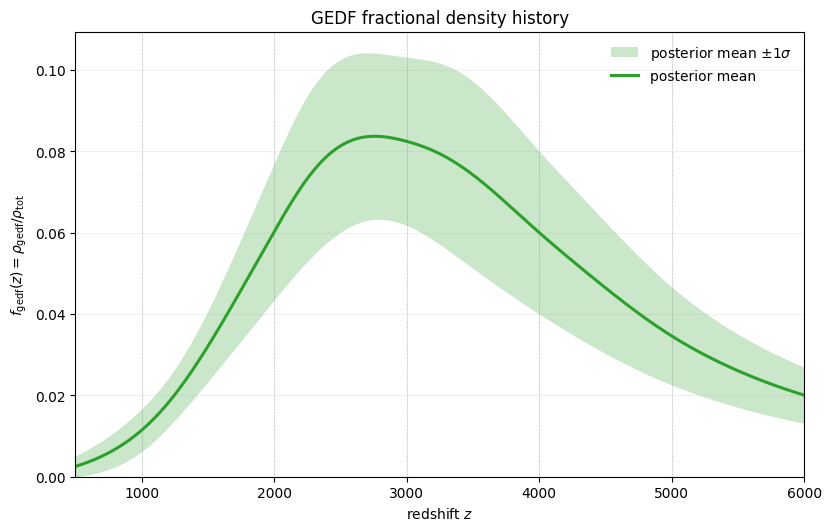

In [7]:
fig, ax = plt.subplots(figsize=(8.2, 5.2), constrained_layout=True)
ax.fill_between(
    z, f_gedf_mean - f_gedf_std, f_gedf_mean + f_gedf_std,
    color="C2", alpha=0.25, linewidth=0,
    label=r"posterior mean $\pm1\sigma$",
)
ax.plot(z, f_gedf_mean, color="C2", lw=2.2, label="posterior mean")
for node_z in Z_NODES:
    ax.axvline(node_z, color="0.75", lw=0.7, ls=":", zorder=0)
ax.set(
    xlabel="redshift $z$",
    ylabel=r"$f_{\rm gedf}(z)=\rho_{\rm gedf}/\rho_{\rm tot}$",
    xlim=(z.min(), z.max()),
    title=r"GEDF fractional density history",
)
ax.set_ylim(bottom=0.0)
ax.legend(frameon=False)
ax.grid(alpha=0.18)

f_figure_path = CLASS_DIR / "notebooks" / "f_gedf_z_mcmc_mean_1sigma.png"
fig.savefig(f_figure_path, dpi=180)
print(f"Saved {f_figure_path}")
plt.show()